In [1]:
import earthdaily.earthone as eo
from earthdaily.earthone.catalog import (
    Image, 
    Product, 
    properties as p
)

In [2]:
import sys, yaml
from datetime import datetime
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
from water_quality_utils import create_ndti_product, utm_epsg_from_centroid, apply_cloud_mask

In [4]:
with open("config.yaml", "r") as file:
    config = yaml.load(file, yaml.FullLoader)

In [5]:
auth = eo.auth.Auth.get_default_auth()
org = auth.payload["org"]
user_hash = auth.namespace

In [6]:
run_id =   user_hash + ":" + datetime.utcnow().strftime("%Y%m%d")
print(f"Today's run ID: {run_id}")

Today's run ID: 3935a4c94291fae6f3fedfbaa29a292a8c5687b2:20260618


In [7]:
baseline_product = create_ndti_product(
    f"turbidity-baseline:{run_id}",
    config['baseline_product_name']
)
print(f"Output baseline product:")
baseline_product

Output baseline product:


Product: Demo Turbidity Baseline
  id: earthdaily:turbidity-baseline:3935a4c94291fae6f3fedfbaa29a292a8c5687b2:20260618
  created: Thu Jun 18 14:02:08 2026

In [8]:
# Seasonal baselines would be best here!

In [9]:
aoi_geom = gpd.read_file(config['in_geojson_path']).iloc[0]["geometry"]
epsg = utm_epsg_from_centroid(aoi_geom)
aoi = eo.geo.AOI(aoi_geom, resolution=config['resolution'], crs=f"EPSG:{epsg}")

In [10]:
prod = Product.get(config['s2_pid'])
ic = (
    prod.images()
    .intersects(aoi)
    .filter(config['BASELINE_START'] < p.acquired < config['BASELINE_END'])
    .filter(p.cloud_fraction<config['MAX_CLOUD_FRACTION'])
    .limit(config['MAX_BASELINE_SCENES'])
    .collect()
)
ic

ImageCollection of 5 images
  * Dates: Feb 11, 2023 to Apr 29, 2023
  * Products: esa:sentinel-2:l2a:c1:v1: 5

In [11]:
baseline_ndarr, info = ic.stack(config['bands'], raster_info=True)
baseline_scl = ic.stack(["scl"])
baseline_dates = list(ic.each.acquired)
baseline_ndarr.shape

(5, 3, 1629, 1295)

In [12]:
baseline_ndarr = apply_cloud_mask(baseline_ndarr, baseline_scl)

In [13]:
# True where pixel is invalid (cloud, nodata, etc.) - use whichever band you already have
invalid = np.isnan(baseline_ndarr[:,0]) if not np.ma.is_masked(baseline_ndarr[:,0]) else np.ma.getmaskarray(baseline_ndarr[:,0])

coverage = 1 - invalid.reshape(invalid.shape[0], -1).mean(axis=1)
keep = coverage >= 0.3

In [14]:
baseline_ndarr = baseline_ndarr[keep]
baseline_ndarr.shape

(5, 3, 1629, 1295)

In [15]:
dates_filtered = [d for d, k in zip(baseline_dates, keep) if k]

/opt/anaconda3/envs/earthone/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


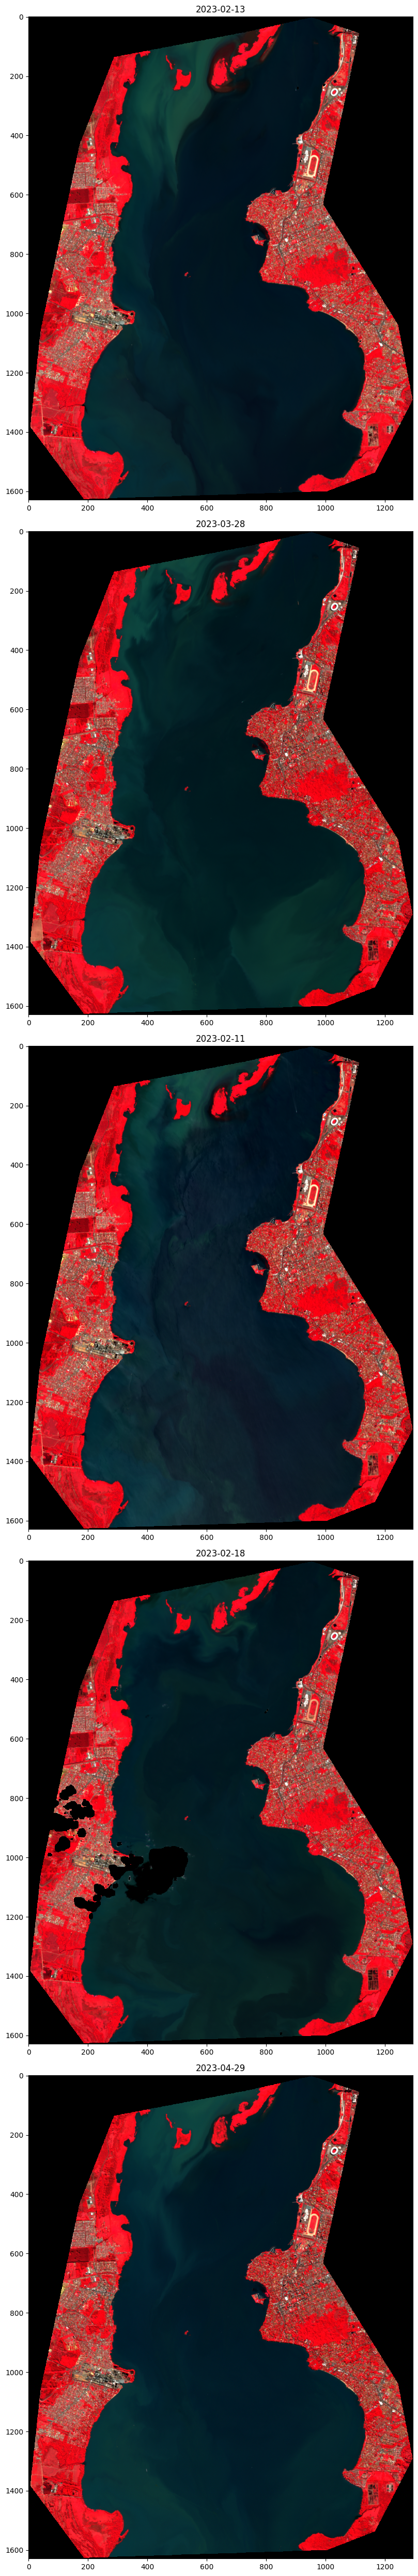

In [16]:
eo.utils.display(*baseline_ndarr, title=[d.strftime("%Y-%m-%d") for d in dates_filtered])

In [17]:
nir = baseline_ndarr[:,0]#.filled(np.nan).astype("float32")
red = baseline_ndarr[:,1]#.filled(np.nan).astype("float32")
green = baseline_ndarr[:,2]#.filled(np.nan).astype("float32")

In [18]:
ndwi = (green - nir) / (green + nir)
ndti = (red - green) / (red + green)

/var/folders/9j/l3nzlch15qz33v5q9lhm5dcw0000gp/T/ipykernel_18988/3607928298.py:1: RuntimeWarning: divide by zero encountered in divide
  ndwi = (green - nir) / (green + nir)
/var/folders/9j/l3nzlch15qz33v5q9lhm5dcw0000gp/T/ipykernel_18988/3607928298.py:2: RuntimeWarning: divide by zero encountered in divide
  ndti = (red - green) / (red + green)
/var/folders/9j/l3nzlch15qz33v5q9lhm5dcw0000gp/T/ipykernel_18988/3607928298.py:2: RuntimeWarning: invalid value encountered in divide
  ndti = (red - green) / (red + green)


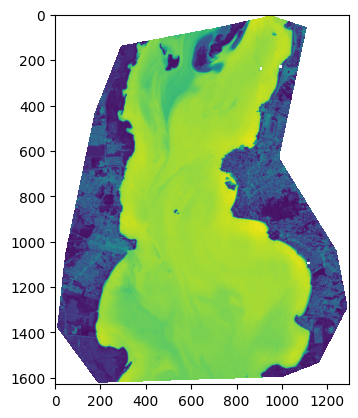

In [19]:
plt.imshow(ndwi[0])

In [20]:
ndti_water = np.where(ndwi > 0, ndti, np.nan)

In [21]:
valid_count = np.sum(~np.isnan(ndti_water), axis=0)

In [22]:
print("Median valid scenes per pixel (water only):", np.median(valid_count[valid_count > 0]))
print("Max valid scenes per pixel:", valid_count.max())
print("Pixels with at least 1 valid scene:", np.sum(valid_count > 0))

Median valid scenes per pixel (water only): 5.0
Max valid scenes per pixel: 5
Pixels with at least 1 valid scene: 1050233


In [23]:
ndti_baseline = np.nanpercentile(ndti_water, config['BASELINE_NDTI_PERCENTILE'], axis=0) 
ndti_baseline[valid_count < config['MIN_VALID_OBSERVATIONS']] = np.nan

/opt/anaconda3/envs/earthone/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/var/folders/9j/l3nzlch15qz33v5q9lhm5dcw0000gp/T/ipykernel_18988/1228836701.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrBr").copy()


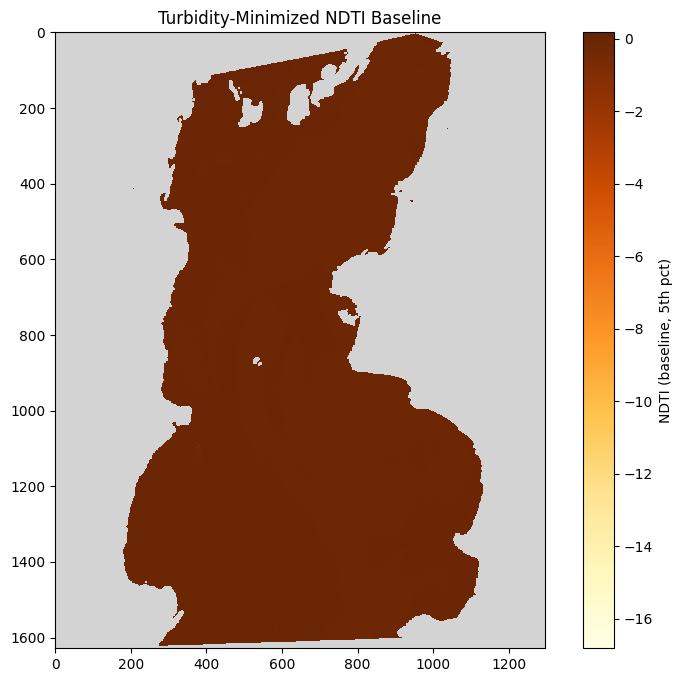

In [24]:
cmap = cm.get_cmap("YlOrBr").copy()
cmap.set_bad("lightgrey")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(ndti_baseline, cmap=cmap)
plt.colorbar(im, ax=ax, label=f"NDTI (baseline, {config['BASELINE_NDTI_PERCENTILE']}th pct)")
ax.set_title("Turbidity-Minimized NDTI Baseline")
plt.show()

In [25]:
baseline_p90 = float(np.nanpercentile(ndti_baseline, 90))
baseline_image = Image(
    name="baseline",
    product=baseline_product,
    acquired=config['BASELINE_END'],
    extra_properties={
        "baseline_start":sorted(dates_filtered)[0].strftime("%Y-%m-%d"), 
        "baseline_end": sorted(dates_filtered)[-1].strftime("%Y-%m-%d"),
        "baseline_scene_count": len(dates_filtered),
        "baseline_percentile": config['BASELINE_NDTI_PERCENTILE'],
        "ndti_p90": baseline_p90
    },
    geometry=aoi.geometry,
)
upload = baseline_image.upload_ndarray(
    ndti_baseline,
    overviews=[2,4,8,16,32,64],
    overview_resampler='nearest',
    overwrite=True,
    raster_meta=info[0],
)
upload.wait_for_completion()

In [ ]:
### Cleaning up old iterations of this product
for prod in Product.search().filter(p.owners==f"user:{auth.namespace}").filter(p.tags=="water-quality-examples").collect():
    status = prod.delete_related_objects()
    if status:
        status.wait_for_completion()
    prod.delete()